# Weekly LSTM Classifier Training

This notebook trains the baseline weekly LSTM classifier from the sequence arrays prepared by `LSTM_input_weekly.ipynb`.

The target is binary: `0 = Bearish next week`, `1 = Bullish next week`. The model predicts the probability that the next week is bullish.

No HMM features are used in this notebook. The HMM-informed weekly LSTM will be built later after `hmm_regime_weekly.ipynb` creates weekly regime probabilities.

## 1. Imports and configuration

In [35]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight

try:
    from weekly_lstm_architecture import (
        WeeklyLSTMConfig,
        build_weekly_lstm_classifier,
        evaluate_binary_classifier,
        get_weekly_callbacks,
        set_global_seed,
    )
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "weekly_lstm_training.ipynb requires TensorFlow. Install a TensorFlow-compatible Python environment before training."
    ) from exc

set_global_seed(5)

SEQUENCE_DIR = Path("outputs/weekly/sequences")
SEQUENCE_METADATA_PATH = Path("outputs/weekly/weekly_sequence_metadata.csv")
MODEL_DIR = Path("models/weekly_lstm")
OUTPUT_DIR = Path("outputs/weekly_lstm")
PLOT_DIR = OUTPUT_DIR / "plots"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("default")
plt.rcParams.update({
    "figure.titlesize": 14,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

MODEL_COLORS = {
    "weekly_lstm": "tab:blue",
    "majority_class": "tab:orange",
    "always_bullish": "tab:green",
    "always_bearish": "tab:red",
}

STATE_COLORS = {
    "Bearish": "tab:red",
    "Bullish": "tab:green",
}

tickers = ["AAPL", "IBM", "MSFT"]
lookbacks = [4, 8, 12, 26]
THRESHOLD_GRID = np.round(np.arange(0.05, 0.951, 0.01), 2)
DEGENERATE_SHARE_CUTOFF = 0.05

EPOCHS = 80
BATCH_SIZE = 16
PATIENCE = 12

MAIN_CONFIG = WeeklyLSTMConfig(
    lstm_units=(16,),
    dense_units=(8,),
    dropout=0.20,
    recurrent_dropout=0.0,
    learning_rate=1e-3,
)

print("Sequence directory:", SEQUENCE_DIR)
print("Model directory:", MODEL_DIR)
print("Output directory:", OUTPUT_DIR)
print("Plot directory:", PLOT_DIR)
print("Tickers:", tickers)
print("Lookbacks:", lookbacks)
print("Decision threshold grid:", (THRESHOLD_GRID.min(), THRESHOLD_GRID.max(), len(THRESHOLD_GRID)))


Sequence directory: outputs\weekly\sequences
Model directory: models\weekly_lstm
Output directory: outputs\weekly_lstm
Plot directory: outputs\weekly_lstm\plots
Tickers: ['AAPL', 'IBM', 'MSFT']
Lookbacks: [4, 8, 12, 26]
Decision threshold grid: (np.float64(0.05), np.float64(0.95), 91)


## 2. Load sequence files

In [36]:
def load_sequence_file(ticker: str, lookback: int) -> dict:
    path = SEQUENCE_DIR / f"{ticker}_lookback_{lookback}.npz"

    if not path.exists():
        raise FileNotFoundError(f"Missing sequence file: {path}")

    data = np.load(path, allow_pickle=True)

    return {
        "X_train": data["X_train"],
        "y_train": data["y_train"].astype(int),
        "X_val": data["X_val"],
        "y_val": data["y_val"].astype(int),
        "X_test": data["X_test"],
        "y_test": data["y_test"].astype(int),
        "feature_cols": [str(col) for col in data["feature_cols"].tolist()],
        "lookback": int(data["lookback"]),
        "ticker": str(data["ticker"]),
        "path": path,
    }


sequence_metadata_df = pd.read_csv(SEQUENCE_METADATA_PATH) if SEQUENCE_METADATA_PATH.exists() else pd.DataFrame()

sequence_overview_rows = []

for ticker in tickers:
    for lookback in lookbacks:
        data = load_sequence_file(ticker, lookback)
        sequence_overview_rows.append(
            {
                "Ticker": ticker,
                "Lookback": lookback,
                "X_train_shape": data["X_train"].shape,
                "y_train_shape": data["y_train"].shape,
                "X_val_shape": data["X_val"].shape,
                "y_val_shape": data["y_val"].shape,
                "X_test_shape": data["X_test"].shape,
                "y_test_shape": data["y_test"].shape,
                "n_features": data["X_train"].shape[2],
                "feature_count": len(data["feature_cols"]),
            }
        )

sequence_overview_df = pd.DataFrame(sequence_overview_rows)
display(sequence_overview_df)

if not sequence_overview_df["n_features"].eq(15).all():
    raise ValueError("Expected all weekly LSTM sequence files to contain 15 features.")


,Ticker,Lookback,X_train_shape,y_train_shape,X_val_shape,y_val_shape,X_test_shape,y_test_shape,n_features,feature_count
0,AAPL,4,"(562, 4, 15)","(562,)","(121, 4, 15)","(121,)","(122, 4, 15)","(122,)",15,15
1,AAPL,8,"(558, 8, 15)","(558,)","(121, 8, 15)","(121,)","(122, 8, 15)","(122,)",15,15
2,AAPL,12,"(554, 12, 15)","(554,)","(121, 12, 15)","(121,)","(122, 12, 15)","(122,)",15,15
3,AAPL,26,"(540, 26, 15)","(540,)","(121, 26, 15)","(121,)","(122, 26, 15)","(122,)",15,15
4,IBM,4,"(562, 4, 15)","(562,)","(121, 4, 15)","(121,)","(122, 4, 15)","(122,)",15,15
5,IBM,8,"(558, 8, 15)","(558,)","(121, 8, 15)","(121,)","(122, 8, 15)","(122,)",15,15
6,IBM,12,"(554, 12, 15)","(554,)","(121, 12, 15)","(121,)","(122, 12, 15)","(122,)",15,15
7,IBM,26,"(540, 26, 15)","(540,)","(121, 26, 15)","(121,)","(122, 26, 15)","(122,)",15,15
8,MSFT,4,"(562, 4, 15)","(562,)","(121, 4, 15)","(121,)","(122, 4, 15)","(122,)",15,15
9,MSFT,8,"(558, 8, 15)","(558,)","(121, 8, 15)","(121,)","(122, 8, 15)","(122,)",15,15


## 3. Naive benchmarks

Benchmarks are evaluated before trusting the LSTM. The majority-class benchmark uses the training split only to decide whether it should always predict bearish or bullish.

In [37]:
def make_benchmark_rows(ticker: str, lookback: int, data: dict) -> list[dict]:
    y_train = data["y_train"]

    if len(y_train) == 0:
        raise ValueError(f"{ticker} lookback={lookback} has no training targets for benchmark creation.")

    majority_class = int(np.mean(y_train) >= 0.5)
    benchmark_classes = {
        "majority_class": majority_class,
        "always_bullish": 1,
        "always_bearish": 0,
    }

    rows = []
    for model_name, predicted_class in benchmark_classes.items():
        for split_name, y_true in [("val", data["y_val"]), ("test", data["y_test"])]:
            y_prob = np.full(shape=len(y_true), fill_value=float(predicted_class), dtype=float)
            metrics = evaluate_binary_classifier(y_true, y_prob)
            rows.append(
                {
                    "ticker": ticker,
                    "lookback": lookback,
                    "model": model_name,
                    "split": split_name,
                    "train_sequences": len(data["y_train"]),
                    "val_sequences": len(data["y_val"]),
                    "test_sequences": len(data["y_test"]),
                    "n_features": data["X_train"].shape[2],
                    "predicted_class": predicted_class,
                    **metrics,
                }
            )

    return rows


benchmark_rows = []
for ticker in tickers:
    for lookback in lookbacks:
        benchmark_rows.extend(make_benchmark_rows(ticker, lookback, load_sequence_file(ticker, lookback)))

weekly_benchmark_results_df = pd.DataFrame(benchmark_rows)
display(weekly_benchmark_results_df.head(12))
display(
    weekly_benchmark_results_df
    .loc[weekly_benchmark_results_df["split"] == "test"]
    .sort_values(["ticker", "lookback", "balanced_accuracy"], ascending=[True, True, False])
)


,ticker,lookback,model,split,train_sequences,val_sequences,test_sequences,n_features,predicted_class,accuracy,balanced_accuracy,f1,cohen_kappa,share_predicted_bullish,share_actual_bullish,roc_auc,tn,fp,fn,tp
0,AAPL,4,majority_class,val,562,121,122,15,1,0.545455,0.5,0.705882,0.0,1.0,0.545455,0.5,0,55,0,66
1,AAPL,4,majority_class,test,562,121,122,15,1,0.549180,0.5,0.708995,0.0,1.0,0.549180,0.5,0,55,0,67
2,AAPL,4,always_bullish,val,562,121,122,15,1,0.545455,0.5,0.705882,0.0,1.0,0.545455,0.5,0,55,0,66
3,AAPL,4,always_bullish,test,562,121,122,15,1,0.549180,0.5,0.708995,0.0,1.0,0.549180,0.5,0,55,0,67
4,AAPL,4,always_bearish,val,562,121,122,15,0,0.454545,0.5,0.000000,0.0,0.0,0.545455,0.5,55,0,66,0
5,AAPL,4,always_bearish,test,562,121,122,15,0,0.450820,0.5,0.000000,0.0,0.0,0.549180,0.5,55,0,67,0
6,AAPL,8,majority_class,val,558,121,122,15,1,0.545455,0.5,0.705882,0.0,1.0,0.545455,0.5,0,55,0,66
7,AAPL,8,majority_class,test,558,121,122,15,1,0.549180,0.5,0.708995,0.0,1.0,0.549180,0.5,0,55,0,67
8,AAPL,8,always_bullish,val,558,121,122,15,1,0.545455,0.5,0.705882,0.0,1.0,0.545455,0.5,0,55,0,66
9,AAPL,8,always_bullish,test,558,121,122,15,1,0.549180,0.5,0.708995,0.0,1.0,0.549180,0.5,0,55,0,67


,ticker,lookback,model,split,train_sequences,val_sequences,test_sequences,n_features,predicted_class,accuracy,balanced_accuracy,f1,cohen_kappa,share_predicted_bullish,share_actual_bullish,roc_auc,tn,fp,fn,tp
1,AAPL,4,majority_class,test,562,121,122,15,1,0.549180,0.5,0.708995,0.0,1.0,0.549180,0.5,0,55,0,67
3,AAPL,4,always_bullish,test,562,121,122,15,1,0.549180,0.5,0.708995,0.0,1.0,0.549180,0.5,0,55,0,67
5,AAPL,4,always_bearish,test,562,121,122,15,0,0.450820,0.5,0.000000,0.0,0.0,0.549180,0.5,55,0,67,0
7,AAPL,8,majority_class,test,558,121,122,15,1,0.549180,0.5,0.708995,0.0,1.0,0.549180,0.5,0,55,0,67
9,AAPL,8,always_bullish,test,558,121,122,15,1,0.549180,0.5,0.708995,0.0,1.0,0.549180,0.5,0,55,0,67
11,AAPL,8,always_bearish,test,558,121,122,15,0,0.450820,0.5,0.000000,0.0,0.0,0.549180,0.5,55,0,67,0
13,AAPL,12,majority_class,test,554,121,122,15,1,0.549180,0.5,0.708995,0.0,1.0,0.549180,0.5,0,55,0,67
15,AAPL,12,always_bullish,test,554,121,122,15,1,0.549180,0.5,0.708995,0.0,1.0,0.549180,0.5,0,55,0,67
17,AAPL,12,always_bearish,test,554,121,122,15,0,0.450820,0.5,0.000000,0.0,0.0,0.549180,0.5,55,0,67,0
19,AAPL,26,majority_class,test,540,121,122,15,1,0.549180,0.5,0.708995,0.0,1.0,0.549180,0.5,0,55,0,67


## 4. Train one weekly LSTM per ticker and lookback

In [38]:
def select_threshold_by_validation_balanced_accuracy(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    thresholds: np.ndarray = THRESHOLD_GRID,
) -> tuple[float, float, pd.DataFrame]:
    """Choose a decision threshold using validation balanced accuracy only."""
    rows = []
    for threshold in thresholds:
        metrics = evaluate_binary_classifier(y_true, y_prob, threshold=float(threshold))
        rows.append(
            {
                "threshold": float(threshold),
                "balanced_accuracy": metrics["balanced_accuracy"],
                "accuracy": metrics["accuracy"],
                "f1": metrics["f1"],
                "cohen_kappa": metrics["cohen_kappa"],
                "share_predicted_bullish": metrics["share_predicted_bullish"],
            }
        )

    threshold_df = pd.DataFrame(rows)
    threshold_df["distance_from_0_5"] = (threshold_df["threshold"] - 0.5).abs()
    best_row = (
        threshold_df
        .sort_values(["balanced_accuracy", "distance_from_0_5"], ascending=[False, True])
        .iloc[0]
    )

    return float(best_row["threshold"]), float(best_row["balanced_accuracy"]), threshold_df.drop(columns="distance_from_0_5")


def make_balanced_class_weight(y_train: np.ndarray) -> dict[int, float]:
    y_train = np.asarray(y_train).reshape(-1).astype(int)
    observed_classes = set(np.unique(y_train).tolist())
    if observed_classes != {0, 1}:
        raise ValueError(f"Class weights require both classes in y_train, got {sorted(observed_classes)}")

    class_weight_values = compute_class_weight(
        class_weight="balanced",
        classes=np.array([0, 1]),
        y=y_train,
    )
    return {0: float(class_weight_values[0]), 1: float(class_weight_values[1])}


def is_degenerate_prediction(share_predicted_bullish: float) -> bool:
    return bool(
        share_predicted_bullish <= DEGENERATE_SHARE_CUTOFF
        or share_predicted_bullish >= 1 - DEGENERATE_SHARE_CUTOFF
    )


def degenerate_prediction_direction(share_predicted_bullish: float) -> str:
    if share_predicted_bullish <= DEGENERATE_SHARE_CUTOFF:
        return "almost_all_bearish"
    if share_predicted_bullish >= 1 - DEGENERATE_SHARE_CUTOFF:
        return "almost_all_bullish"
    return ""


def make_prediction_frame(
    ticker: str,
    lookback: int,
    split: str,
    y_true: np.ndarray,
    y_prob: np.ndarray,
    decision_threshold: float,
) -> pd.DataFrame:
    frame = pd.DataFrame(
        {
            "Ticker": ticker,
            "Lookback": lookback,
            "Split": split,
            "Sequence_Index": np.arange(len(y_true)),
            "Decision_Threshold": float(decision_threshold),
            "y_true": y_true.astype(int),
            "y_prob": y_prob,
            "y_pred": (y_prob >= decision_threshold).astype(int),
        }
    )

    if not sequence_metadata_df.empty:
        meta = (
            sequence_metadata_df
            .loc[
                (sequence_metadata_df["Ticker"] == ticker)
                & (sequence_metadata_df["Lookback"] == lookback)
                & (sequence_metadata_df["Split"] == split)
            ]
            .reset_index(drop=True)
        )
        if len(meta) == len(frame):
            frame.insert(3, "Date", meta["Date"])
            frame.insert(4, "Target_Date", meta["Target_Date"])

    return frame


def train_weekly_lstm_one_setting(
    ticker: str,
    lookback: int,
    epochs: int = EPOCHS,
    batch_size: int = BATCH_SIZE,
    patience: int = PATIENCE,
    config: WeeklyLSTMConfig = MAIN_CONFIG,
):
    data = load_sequence_file(ticker, lookback)

    X_train = data["X_train"]
    y_train = data["y_train"]
    X_val = data["X_val"]
    y_val = data["y_val"]
    X_test = data["X_test"]
    y_test = data["y_test"]

    if min(len(y_train), len(y_val), len(y_test)) == 0:
        raise ValueError(
            f"{ticker} lookback={lookback} has an empty split: "
            f"train={len(y_train)}, val={len(y_val)}, test={len(y_test)}"
        )

    class_weight = make_balanced_class_weight(y_train)
    print(f"Class weights for {ticker} lookback={lookback}: {class_weight}")

    model = build_weekly_lstm_classifier(
        input_shape=(X_train.shape[1], X_train.shape[2]),
        config=config,
    )

    model_path = MODEL_DIR / f"weekly_lstm_{ticker}_lookback_{lookback}.keras"

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=get_weekly_callbacks(model_path, patience=patience),
        class_weight=class_weight,
        shuffle=False,
        verbose=1,
    )

    val_prob = model.predict(X_val, verbose=0).reshape(-1)
    test_prob = model.predict(X_test, verbose=0).reshape(-1)

    decision_threshold, best_threshold_balanced_accuracy, threshold_search_df = select_threshold_by_validation_balanced_accuracy(
        y_val,
        val_prob,
    )
    threshold_search_df.insert(0, "lookback", lookback)
    threshold_search_df.insert(0, "ticker", ticker)

    val_metrics = evaluate_binary_classifier(y_val, val_prob, threshold=decision_threshold)
    test_metrics = evaluate_binary_classifier(y_test, test_prob, threshold=decision_threshold)

    test_share_predicted_bullish = test_metrics["share_predicted_bullish"]
    degenerate_warning = is_degenerate_prediction(test_share_predicted_bullish)
    degenerate_direction = degenerate_prediction_direction(test_share_predicted_bullish)

    if degenerate_warning:
        print(
            "WARNING: "
            f"{ticker} lookback={lookback} predicts {test_share_predicted_bullish:.1%} Bullish on the test set "
            f"after validation-threshold selection ({degenerate_direction})."
        )

    result_row = {
        "ticker": ticker,
        "lookback": lookback,
        "model": "weekly_lstm",
        "train_sequences": len(y_train),
        "val_sequences": len(y_val),
        "test_sequences": len(y_test),
        "n_features": X_train.shape[2],
        "class_weight_0": class_weight[0],
        "class_weight_1": class_weight[1],
        "decision_threshold": decision_threshold,
        "best_val_threshold_balanced_accuracy": best_threshold_balanced_accuracy,
        "degenerate_prediction_warning": degenerate_warning,
        "degenerate_prediction_direction": degenerate_direction,
        "best_val_loss": float(np.min(history.history["val_loss"])),
        "best_val_auc": float(np.max(history.history["val_auc"])),
        "epochs_run": len(history.history["loss"]),
        **{f"val_{k}": v for k, v in val_metrics.items()},
        **{f"test_{k}": v for k, v in test_metrics.items()},
    }

    prediction_frame = pd.concat(
        [
            make_prediction_frame(ticker, lookback, "validation", y_val, val_prob, decision_threshold),
            make_prediction_frame(ticker, lookback, "test", y_test, test_prob, decision_threshold),
        ],
        ignore_index=True,
    )

    history_frame = pd.DataFrame(history.history)
    history_frame.insert(0, "epoch", np.arange(1, len(history_frame) + 1))
    history_frame.insert(0, "lookback", lookback)
    history_frame.insert(0, "ticker", ticker)

    return result_row, prediction_frame, history_frame, threshold_search_df


In [39]:
result_rows = []
prediction_frames = []
history_frames = []
threshold_search_frames = []

for ticker in tickers:
    for lookback in lookbacks:
        print("=" * 80)
        print(f"Training {ticker}, lookback={lookback}")
        print("=" * 80)

        row, preds, history_frame, threshold_search_df = train_weekly_lstm_one_setting(
            ticker=ticker,
            lookback=lookback,
        )

        result_rows.append(row)
        prediction_frames.append(preds)
        history_frames.append(history_frame)
        threshold_search_frames.append(threshold_search_df)

weekly_lstm_results_df = pd.DataFrame(result_rows)
weekly_lstm_predictions_df = pd.concat(prediction_frames, ignore_index=True)
weekly_lstm_history_df = pd.concat(history_frames, ignore_index=True)
weekly_lstm_threshold_search_df = pd.concat(threshold_search_frames, ignore_index=True)

sort_cols = ["ticker", "val_roc_auc", "val_balanced_accuracy"]
display(
    weekly_lstm_results_df
    .sort_values(sort_cols, ascending=[True, False, False])
)


Training AAPL, lookback=4
Class weights for AAPL lookback=4: {0: 1.206008583690987, 1: 0.8541033434650456}
Epoch 1/80
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5302 - auc: 0.5245 - loss: 0.6935 - precision: 0.5964 - recall: 0.6109 - val_accuracy: 0.4876 - val_auc: 0.4875 - val_loss: 0.6942 - val_precision: 0.5303 - val_recall: 0.5303 - learning_rate: 0.0010
Epoch 2/80
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5427 - auc: 0.5326 - loss: 0.6917 - precision: 0.6192 - recall: 0.5684 - val_accuracy: 0.4628 - val_auc: 0.5091 - val_loss: 0.6924 - val_precision: 0.5085 - val_recall: 0.4545 - learning_rate: 0.0010
Epoch 3/80
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5214 - auc: 0.5578 - loss: 0.6882 - precision: 0.6056 - recall: 0.5228 - val_accuracy: 0.4876 - val_auc: 0.5118 - val_loss: 0.6907 - val_precision: 0.5400 - val_recall: 0.4091 - learning_rate: 0.0010
Epoch 4/80
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5142 - auc: 0.5148 - loss: 0.6930 - 

,ticker,lookback,model,train_sequences,val_sequences,test_sequences,n_features,class_weight_0,class_weight_1,decision_threshold,...,test_balanced_accuracy,test_f1,test_cohen_kappa,test_share_predicted_bullish,test_share_actual_bullish,test_roc_auc,test_tn,test_fp,test_fn,test_tp
3,AAPL,26,weekly_lstm,540,121,122,15,1.200000,0.857143,0.52,...,0.507734,0.272727,0.014390,0.172131,0.549180,0.543555,46,9,55,12
2,AAPL,12,weekly_lstm,554,121,122,15,1.199134,0.857585,0.51,...,0.535278,0.438095,0.067375,0.311475,0.549180,0.554681,40,15,44,23
1,AAPL,8,weekly_lstm,558,121,122,15,1.207792,0.853211,0.50,...,0.494980,0.500000,-0.009880,0.467213,0.549180,0.518318,29,26,36,31
0,AAPL,4,weekly_lstm,562,121,122,15,1.206009,0.854103,0.51,...,0.468114,0.291667,-0.060056,0.237705,0.549180,0.467028,40,15,53,14
6,IBM,12,weekly_lstm,554,121,122,15,1.041353,0.961806,0.52,...,0.488457,0.141176,-0.018760,0.090164,0.606557,0.564189,43,5,68,6
7,IBM,26,weekly_lstm,540,121,122,15,1.030534,0.971223,0.55,...,0.513514,0.052632,0.021390,0.016393,0.606557,0.585867,48,0,72,2
5,IBM,8,weekly_lstm,558,121,122,15,1.048872,0.955479,0.55,...,0.506194,0.100000,0.009919,0.049180,0.606557,0.549550,46,2,70,4
4,IBM,4,weekly_lstm,562,121,122,15,1.044610,0.959044,0.51,...,0.508164,0.258065,0.013593,0.155738,0.606557,0.612613,41,7,62,12
10,MSFT,12,weekly_lstm,554,121,122,15,1.214912,0.849693,0.49,...,0.472792,0.515152,-0.053711,0.516393,0.565574,0.462401,24,29,35,34
11,MSFT,26,weekly_lstm,540,121,122,15,1.216216,0.849057,0.50,...,0.539787,0.279070,0.071446,0.139344,0.565574,0.555100,48,5,57,12


## 5. Save metrics and predictions

In [40]:
benchmark_wide_df = (
    weekly_benchmark_results_df
    .pivot_table(
        index=["ticker", "lookback", "model", "train_sequences", "val_sequences", "test_sequences", "n_features"],
        columns="split",
        values=[
            "accuracy",
            "balanced_accuracy",
            "f1",
            "cohen_kappa",
            "share_predicted_bullish",
            "share_actual_bullish",
            "roc_auc",
            "tn",
            "fp",
            "fn",
            "tp",
        ],
    )
)
benchmark_wide_df.columns = [f"{split}_{metric}" for metric, split in benchmark_wide_df.columns]
benchmark_wide_df = benchmark_wide_df.reset_index()
benchmark_wide_df["class_weight_0"] = np.nan
benchmark_wide_df["class_weight_1"] = np.nan
benchmark_wide_df["decision_threshold"] = 0.5
benchmark_wide_df["best_val_threshold_balanced_accuracy"] = benchmark_wide_df["val_balanced_accuracy"]
benchmark_wide_df["degenerate_prediction_warning"] = benchmark_wide_df["test_share_predicted_bullish"].apply(is_degenerate_prediction)
benchmark_wide_df["degenerate_prediction_direction"] = benchmark_wide_df["test_share_predicted_bullish"].apply(degenerate_prediction_direction)
benchmark_wide_df["best_val_loss"] = np.nan
benchmark_wide_df["best_val_auc"] = np.nan
benchmark_wide_df["epochs_run"] = 0

weekly_lstm_all_results_df = pd.concat(
    [weekly_lstm_results_df, benchmark_wide_df],
    ignore_index=True,
    sort=False,
)

weekly_lstm_results_df.to_csv(OUTPUT_DIR / "weekly_lstm_results.csv", index=False)
weekly_lstm_predictions_df.to_csv(OUTPUT_DIR / "weekly_lstm_predictions.csv", index=False)
weekly_lstm_history_df.to_csv(OUTPUT_DIR / "weekly_lstm_training_history.csv", index=False)
weekly_lstm_threshold_search_df.to_csv(OUTPUT_DIR / "weekly_lstm_threshold_search.csv", index=False)
weekly_benchmark_results_df.to_csv(OUTPUT_DIR / "weekly_lstm_benchmark_results_long.csv", index=False)
benchmark_wide_df.to_csv(OUTPUT_DIR / "weekly_lstm_benchmark_results.csv", index=False)
weekly_lstm_all_results_df.to_csv(OUTPUT_DIR / "weekly_lstm_all_results.csv", index=False)

print("Saved:")
for name in [
    "weekly_lstm_results.csv",
    "weekly_lstm_predictions.csv",
    "weekly_lstm_training_history.csv",
    "weekly_lstm_threshold_search.csv",
    "weekly_lstm_benchmark_results_long.csv",
    "weekly_lstm_benchmark_results.csv",
    "weekly_lstm_all_results.csv",
]:
    print(OUTPUT_DIR / name)


Saved:
outputs\weekly_lstm\weekly_lstm_results.csv
outputs\weekly_lstm\weekly_lstm_predictions.csv
outputs\weekly_lstm\weekly_lstm_training_history.csv
outputs\weekly_lstm\weekly_lstm_threshold_search.csv
outputs\weekly_lstm\weekly_lstm_benchmark_results_long.csv
outputs\weekly_lstm\weekly_lstm_benchmark_results.csv
outputs\weekly_lstm\weekly_lstm_all_results.csv


## 6. Choose the best lookback using validation metrics

The lookback should be selected using validation performance first. The primary metric is validation ROC-AUC, and the secondary metric is validation balanced accuracy. Test performance is reported after selection.

In [41]:
ranked_lstm_df = weekly_lstm_results_df.sort_values(
    ["ticker", "val_roc_auc", "val_balanced_accuracy"],
    ascending=[True, False, False],
).reset_index(drop=True)

best_by_ticker_df = (
    ranked_lstm_df
    .groupby("ticker", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

best_overall_df = weekly_lstm_results_df.sort_values(
    ["val_roc_auc", "val_balanced_accuracy"],
    ascending=[False, False],
).reset_index(drop=True)

best_by_ticker_df.to_csv(OUTPUT_DIR / "weekly_lstm_best_by_ticker.csv", index=False)
best_overall_df.to_csv(OUTPUT_DIR / "weekly_lstm_ranked_results.csv", index=False)

print("Best LSTM setting per ticker, selected by validation metrics:")
display(best_by_ticker_df)

print("All LSTM settings ranked by validation metrics:")
display(best_overall_df)


Best LSTM setting per ticker, selected by validation metrics:


,ticker,lookback,model,train_sequences,val_sequences,test_sequences,n_features,class_weight_0,class_weight_1,decision_threshold,...,test_balanced_accuracy,test_f1,test_cohen_kappa,test_share_predicted_bullish,test_share_actual_bullish,test_roc_auc,test_tn,test_fp,test_fn,test_tp
0,AAPL,26,weekly_lstm,540,121,122,15,1.200000,0.857143,0.52,...,0.507734,0.272727,0.014390,0.172131,0.549180,0.543555,46,9,55,12
1,IBM,12,weekly_lstm,554,121,122,15,1.041353,0.961806,0.52,...,0.488457,0.141176,-0.018760,0.090164,0.606557,0.564189,43,5,68,6
2,MSFT,12,weekly_lstm,554,121,122,15,1.214912,0.849693,0.49,...,0.472792,0.515152,-0.053711,0.516393,0.565574,0.462401,24,29,35,34


All LSTM settings ranked by validation metrics:


,ticker,lookback,model,train_sequences,val_sequences,test_sequences,n_features,class_weight_0,class_weight_1,decision_threshold,...,test_balanced_accuracy,test_f1,test_cohen_kappa,test_share_predicted_bullish,test_share_actual_bullish,test_roc_auc,test_tn,test_fp,test_fn,test_tp
0,AAPL,26,weekly_lstm,540,121,122,15,1.200000,0.857143,0.52,...,0.507734,0.272727,0.014390,0.172131,0.549180,0.543555,46,9,55,12
1,AAPL,12,weekly_lstm,554,121,122,15,1.199134,0.857585,0.51,...,0.535278,0.438095,0.067375,0.311475,0.549180,0.554681,40,15,44,23
2,AAPL,8,weekly_lstm,558,121,122,15,1.207792,0.853211,0.50,...,0.494980,0.500000,-0.009880,0.467213,0.549180,0.518318,29,26,36,31
3,MSFT,12,weekly_lstm,554,121,122,15,1.214912,0.849693,0.49,...,0.472792,0.515152,-0.053711,0.516393,0.565574,0.462401,24,29,35,34
4,IBM,12,weekly_lstm,554,121,122,15,1.041353,0.961806,0.52,...,0.488457,0.141176,-0.018760,0.090164,0.606557,0.564189,43,5,68,6
5,IBM,26,weekly_lstm,540,121,122,15,1.030534,0.971223,0.55,...,0.513514,0.052632,0.021390,0.016393,0.606557,0.585867,48,0,72,2
6,IBM,8,weekly_lstm,558,121,122,15,1.048872,0.955479,0.55,...,0.506194,0.100000,0.009919,0.049180,0.606557,0.549550,46,2,70,4
7,MSFT,26,weekly_lstm,540,121,122,15,1.216216,0.849057,0.50,...,0.539787,0.279070,0.071446,0.139344,0.565574,0.555100,48,5,57,12
8,AAPL,4,weekly_lstm,562,121,122,15,1.206009,0.854103,0.51,...,0.468114,0.291667,-0.060056,0.237705,0.549180,0.467028,40,15,53,14
9,IBM,4,weekly_lstm,562,121,122,15,1.044610,0.959044,0.51,...,0.508164,0.258065,0.013593,0.155738,0.606557,0.612613,41,7,62,12


### Prediction degeneracy warnings

A model that predicts almost every test observation as Bullish or almost every test observation as Bearish should be interpreted cautiously, even if its F1-score looks acceptable. The warning table below flags any LSTM setting where the test predicted bullish share is at or below 5% or at or above 95%.

In [42]:
warning_cols = [
    "ticker",
    "lookback",
    "decision_threshold",
    "val_balanced_accuracy",
    "test_balanced_accuracy",
    "test_f1",
    "val_share_predicted_bullish",
    "test_share_predicted_bullish",
    "degenerate_prediction_warning",
    "degenerate_prediction_direction",
]

degenerate_lstm_df = weekly_lstm_results_df.loc[
    weekly_lstm_results_df["degenerate_prediction_warning"].astype(bool),
    warning_cols,
].copy()

if degenerate_lstm_df.empty:
    print("No weekly LSTM setting predicts almost all Bullish or almost all Bearish on the test set.")
else:
    print(
        "WARNING: The following weekly LSTM settings have degenerate test predictions. "
        "Treat their F1-scores and accuracy with caution."
    )
    display(degenerate_lstm_df)

selected_degenerate_df = best_by_ticker_df.loc[
    best_by_ticker_df["degenerate_prediction_warning"].astype(bool),
    warning_cols,
].copy()
if not selected_degenerate_df.empty:
    print("WARNING: At least one validation-selected model is degenerate on the test set.")
    display(selected_degenerate_df)


,ticker,lookback,decision_threshold,val_balanced_accuracy,test_balanced_accuracy,test_f1,val_share_predicted_bullish,test_share_predicted_bullish,degenerate_prediction_warning,degenerate_prediction_direction
5,IBM,8,0.55,0.545192,0.506194,0.100000,0.173554,0.049180,True,almost_all_bearish
7,IBM,26,0.55,0.547665,0.513514,0.052632,0.140496,0.016393,True,almost_all_bearish


## 7. Research visualizations

These plots are designed for model interpretation and reporting. They compare lookback windows, show whether the LSTM beats naive benchmarks, and inspect the selected models using confusion matrices, ROC curves, probability distributions, and training curves.

In [43]:
from sklearn.metrics import auc, confusion_matrix, roc_curve

saved_result_files = {
    "weekly_lstm_results_df": OUTPUT_DIR / "weekly_lstm_results.csv",
    "weekly_lstm_all_results_df": OUTPUT_DIR / "weekly_lstm_all_results.csv",
    "weekly_lstm_predictions_df": OUTPUT_DIR / "weekly_lstm_predictions.csv",
    "weekly_lstm_history_df": OUTPUT_DIR / "weekly_lstm_training_history.csv",
    "weekly_lstm_threshold_search_df": OUTPUT_DIR / "weekly_lstm_threshold_search.csv",
    "best_by_ticker_df": OUTPUT_DIR / "weekly_lstm_best_by_ticker.csv",
}

if "weekly_lstm_results_df" not in globals() and saved_result_files["weekly_lstm_results_df"].exists():
    weekly_lstm_results_df = pd.read_csv(saved_result_files["weekly_lstm_results_df"])
    weekly_lstm_all_results_df = pd.read_csv(saved_result_files["weekly_lstm_all_results_df"])
    weekly_lstm_predictions_df = pd.read_csv(saved_result_files["weekly_lstm_predictions_df"])
    weekly_lstm_history_df = pd.read_csv(saved_result_files["weekly_lstm_history_df"])
    weekly_lstm_threshold_search_df = pd.read_csv(saved_result_files["weekly_lstm_threshold_search_df"])
    best_by_ticker_df = pd.read_csv(saved_result_files["best_by_ticker_df"])
    print("Reloaded saved weekly LSTM results from disk for plotting.")

EXPECTED_PLOT_FILES = [
    PLOT_DIR / "weekly_lstm_metrics_by_lookback.png",
    PLOT_DIR / "weekly_lstm_vs_naive_benchmarks.png",
    PLOT_DIR / "weekly_lstm_selected_confusion_matrices.png",
    PLOT_DIR / "weekly_lstm_selected_roc_curves.png",
    PLOT_DIR / "weekly_lstm_selected_probability_distributions.png",
    PLOT_DIR / "weekly_lstm_selected_probabilities_over_time.png",
    PLOT_DIR / "weekly_lstm_selected_training_loss.png",
    PLOT_DIR / "weekly_lstm_selected_training_auc.png",
]

saved_plot_paths = []


def save_plot(filename: str) -> Path:
    path = PLOT_DIR / filename
    plt.savefig(path, dpi=300, bbox_inches="tight")
    saved_plot_paths.append(path)
    print(f"Saved plot: {path}")
    return path


def selected_test_predictions() -> pd.DataFrame:
    frames = []
    for row in best_by_ticker_df.itertuples(index=False):
        frame = weekly_lstm_predictions_df.loc[
            (weekly_lstm_predictions_df["Ticker"] == row.ticker)
            & (weekly_lstm_predictions_df["Lookback"] == row.lookback)
            & (weekly_lstm_predictions_df["Split"] == "test")
        ].copy()
        frame["Selected_Lookback"] = row.lookback
        frames.append(frame)

    if not frames:
        raise ValueError("No selected test prediction frames were found.")

    return pd.concat(frames, ignore_index=True)


def threshold_for_selected_ticker(ticker: str) -> float:
    match = best_by_ticker_df.loc[best_by_ticker_df["ticker"] == ticker, "decision_threshold"]
    if match.empty:
        return 0.5
    return float(match.iloc[0])


### Lookback comparison

The first plot compares validation and test performance across the four weekly lookback windows. The lookback should be selected from validation performance, with test performance used only for final reporting.

Saved plot: outputs\weekly_lstm\plots\weekly_lstm_metrics_by_lookback.png


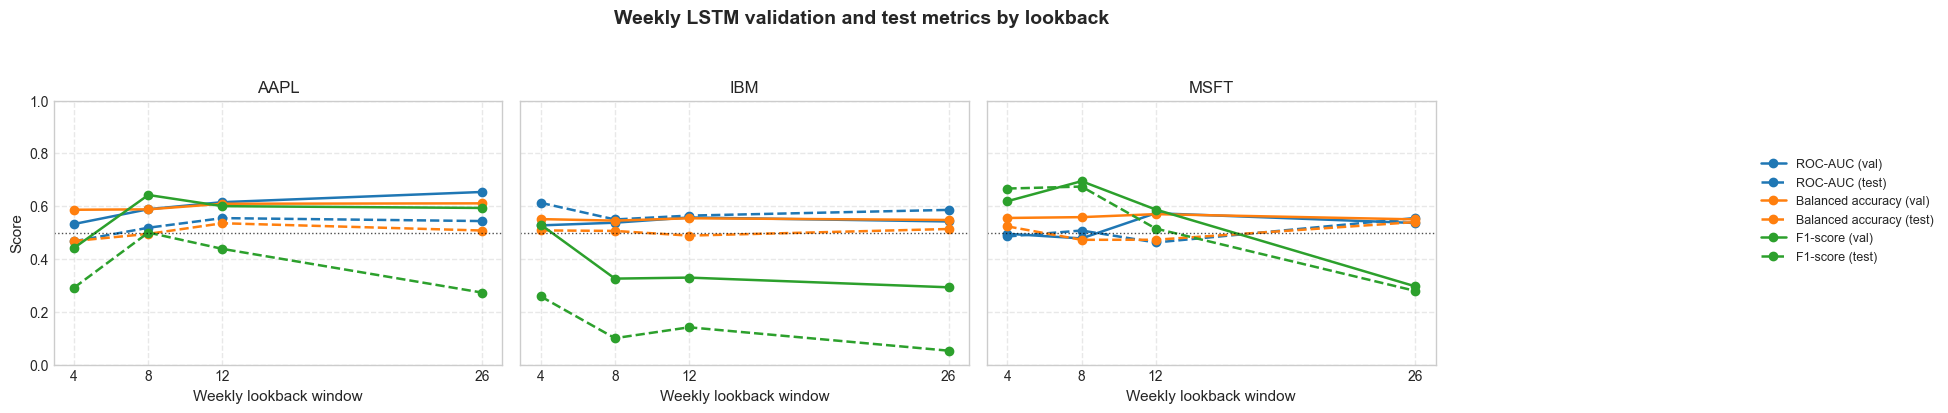

In [44]:
metric_cols = [
    "val_roc_auc",
    "test_roc_auc",
    "val_balanced_accuracy",
    "test_balanced_accuracy",
    "val_f1",
    "test_f1",
]

metric_plot_df = weekly_lstm_results_df.melt(
    id_vars=["ticker", "lookback"],
    value_vars=metric_cols,
    var_name="Metric_Split",
    value_name="Score",
)
metric_plot_df["Split"] = metric_plot_df["Metric_Split"].str.extract(r"^(val|test)_")
metric_plot_df["Metric"] = (
    metric_plot_df["Metric_Split"]
    .str.replace(r"^(val|test)_", "", regex=True)
    .replace({
        "roc_auc": "ROC-AUC",
        "balanced_accuracy": "Balanced accuracy",
        "f1": "F1-score",
    })
)

metric_colors = {
    "ROC-AUC": "tab:blue",
    "Balanced accuracy": "tab:orange",
    "F1-score": "tab:green",
}
split_styles = {
    "val": "-",
    "test": "--",
}

fig, axes = plt.subplots(1, len(tickers), figsize=(5.8 * len(tickers), 4.2), sharey=True)
if len(tickers) == 1:
    axes = [axes]

for ax, ticker in zip(axes, tickers):
    df_t = metric_plot_df.loc[metric_plot_df["ticker"] == ticker]
    for metric, color in metric_colors.items():
        for split, linestyle in split_styles.items():
            series = (
                df_t.loc[(df_t["Metric"] == metric) & (df_t["Split"] == split)]
                .sort_values("lookback")
            )
            ax.plot(
                series["lookback"],
                series["Score"],
                marker="o",
                linestyle=linestyle,
                linewidth=1.8,
                color=color,
                label=f"{metric} ({split})",
            )

    ax.set_title(ticker)
    ax.set_xlabel("Weekly lookback window")
    ax.set_xticks(lookbacks)
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color="black", linestyle=":", linewidth=1, alpha=0.7)
    ax.grid(True, linestyle="--", alpha=0.45)

axes[0].set_ylabel("Score")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
fig.suptitle("Weekly LSTM validation and test metrics by lookback", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 0.84, 0.94])
save_plot("weekly_lstm_metrics_by_lookback.png")
plt.show()


### LSTM versus naive benchmarks

This comparison checks whether the weekly LSTM beats simple rules. For a classification target, beating the majority-class benchmark is the minimum standard before interpreting the LSTM as useful.

Saved plot: outputs\weekly_lstm\plots\weekly_lstm_vs_naive_benchmarks.png


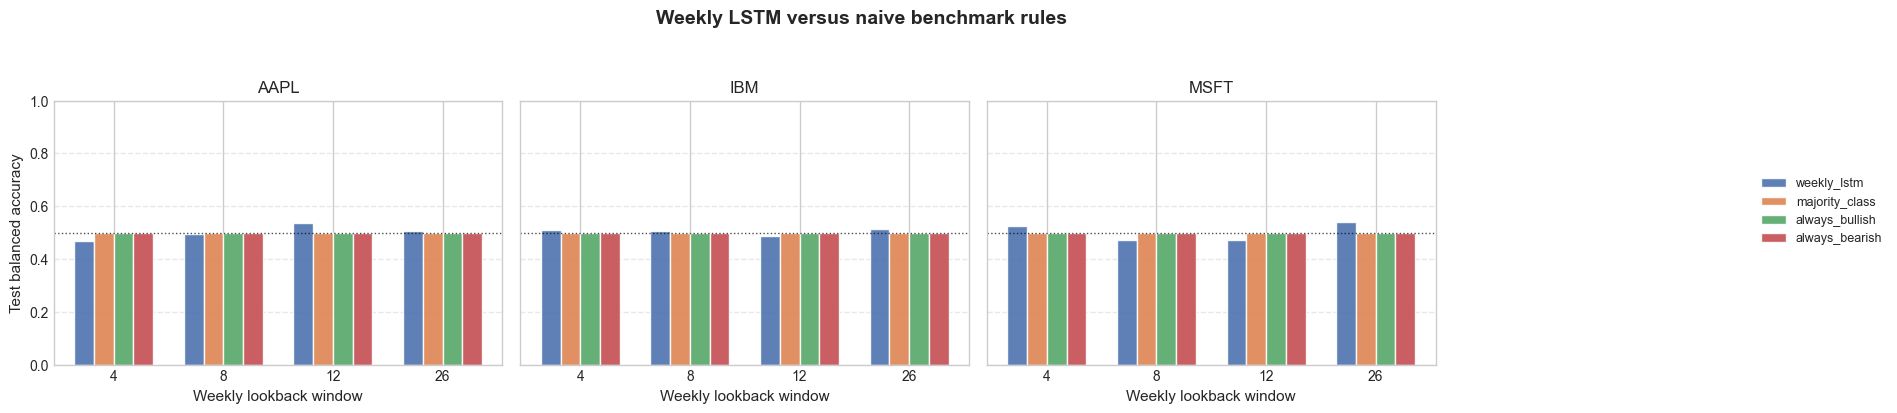

In [45]:
benchmark_plot_df = weekly_lstm_all_results_df[
    ["ticker", "lookback", "model", "test_accuracy", "test_balanced_accuracy", "test_f1", "test_roc_auc"]
].copy()

model_order = ["weekly_lstm", "majority_class", "always_bullish", "always_bearish"]
benchmark_plot_df["model"] = pd.Categorical(benchmark_plot_df["model"], categories=model_order, ordered=True)

fig, axes = plt.subplots(1, len(tickers), figsize=(5.8 * len(tickers), 4.2), sharey=True)
if len(tickers) == 1:
    axes = [axes]

bar_width = 0.18
x_positions = np.arange(len(lookbacks))
offsets = (np.arange(len(model_order)) - (len(model_order) - 1) / 2) * bar_width

for ax, ticker in zip(axes, tickers):
    df_t = benchmark_plot_df.loc[benchmark_plot_df["ticker"] == ticker]
    for offset, model_name in zip(offsets, model_order):
        values = []
        for lookback in lookbacks:
            match = df_t.loc[(df_t["lookback"] == lookback) & (df_t["model"] == model_name), "test_balanced_accuracy"]
            values.append(float(match.iloc[0]) if not match.empty else np.nan)
        ax.bar(
            x_positions + offset,
            values,
            width=bar_width,
            label=model_name,
            alpha=0.9,
        )

    ax.set_title(ticker)
    ax.set_xlabel("Weekly lookback window")
    ax.set_xticks(x_positions)
    ax.set_xticklabels(lookbacks)
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color="black", linestyle=":", linewidth=1, alpha=0.7)
    ax.grid(True, axis="y", linestyle="--", alpha=0.45)

axes[0].set_ylabel("Test balanced accuracy")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
fig.suptitle("Weekly LSTM versus naive benchmark rules", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 0.84, 0.94])
save_plot("weekly_lstm_vs_naive_benchmarks.png")
plt.show()


### Diagnostics for validation-selected models

The next plots use the validation-selected lookback for each ticker and inspect the corresponding test-set predictions.

C:\Users\Admin\AppData\Local\Temp\ipykernel_12736\3193400608.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.96, 0.92])


Saved plot: outputs\weekly_lstm\plots\weekly_lstm_selected_confusion_matrices.png


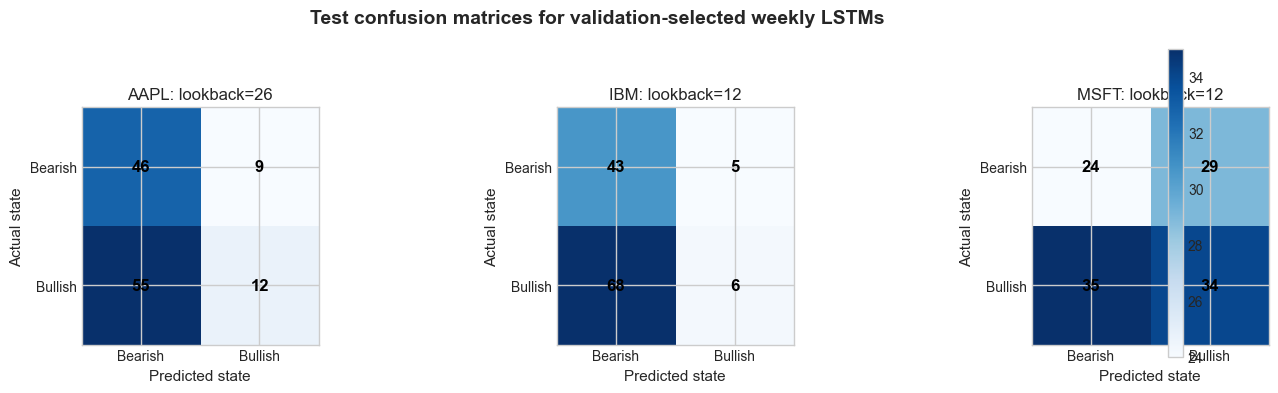

Saved plot: outputs\weekly_lstm\plots\weekly_lstm_selected_roc_curves.png


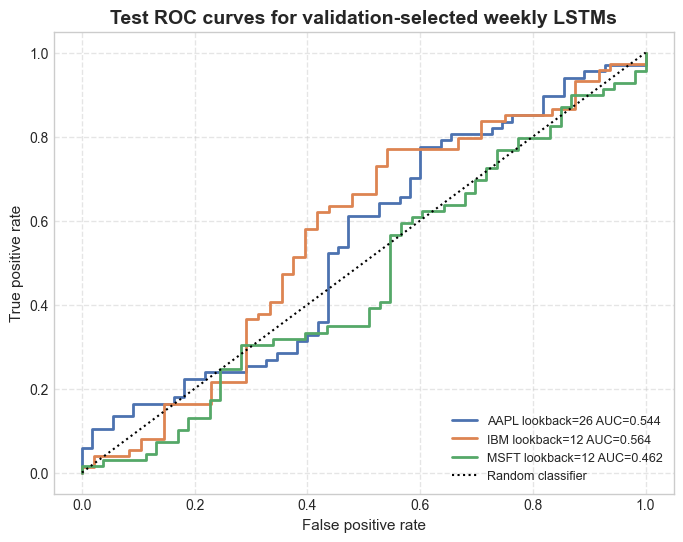

In [46]:
selected_test_df = selected_test_predictions()

fig, axes = plt.subplots(1, len(best_by_ticker_df), figsize=(5 * len(best_by_ticker_df), 4), sharex=False, sharey=False)
if len(best_by_ticker_df) == 1:
    axes = [axes]

for ax, row in zip(axes, best_by_ticker_df.itertuples(index=False)):
    df_t = selected_test_df.loc[selected_test_df["Ticker"] == row.ticker]
    cm = confusion_matrix(df_t["y_true"], df_t["y_pred"], labels=[0, 1])

    image = ax.imshow(cm, cmap="Blues")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black", fontsize=12, fontweight="bold")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Bearish", "Bullish"])
    ax.set_yticklabels(["Bearish", "Bullish"])
    ax.set_title(f"{row.ticker}: lookback={row.lookback}")
    ax.set_xlabel("Predicted state")
    ax.set_ylabel("Actual state")

fig.colorbar(image, ax=axes, fraction=0.025, pad=0.02)
fig.suptitle("Test confusion matrices for validation-selected weekly LSTMs", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 0.96, 0.92])
save_plot("weekly_lstm_selected_confusion_matrices.png")
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
for row in best_by_ticker_df.itertuples(index=False):
    df_t = selected_test_df.loc[selected_test_df["Ticker"] == row.ticker]
    if df_t["y_true"].nunique() < 2:
        continue
    fpr, tpr, _ = roc_curve(df_t["y_true"], df_t["y_prob"])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, label=f"{row.ticker} lookback={row.lookback} AUC={roc_auc:.3f}")

ax.plot([0, 1], [0, 1], color="black", linestyle=":", linewidth=1.5, label="Random classifier")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("Test ROC curves for validation-selected weekly LSTMs", fontsize=14, fontweight="bold")
ax.legend(loc="lower right")
ax.grid(True, linestyle="--", alpha=0.5)
save_plot("weekly_lstm_selected_roc_curves.png")
plt.show()


Saved plot: outputs\weekly_lstm\plots\weekly_lstm_selected_probability_distributions.png


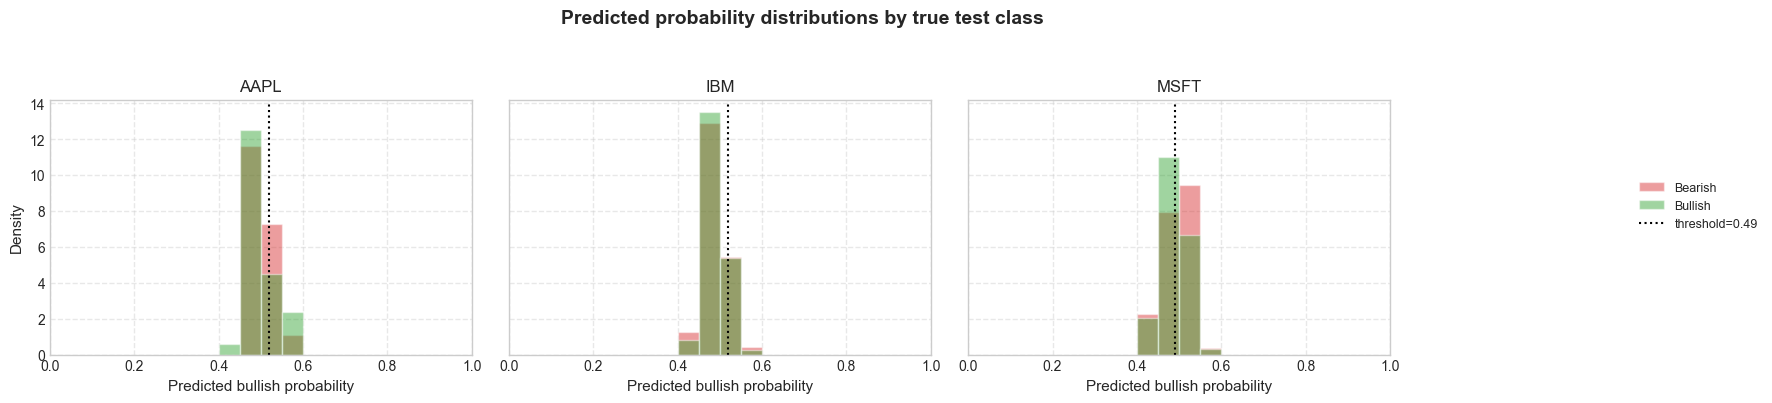

Saved plot: outputs\weekly_lstm\plots\weekly_lstm_selected_probabilities_over_time.png


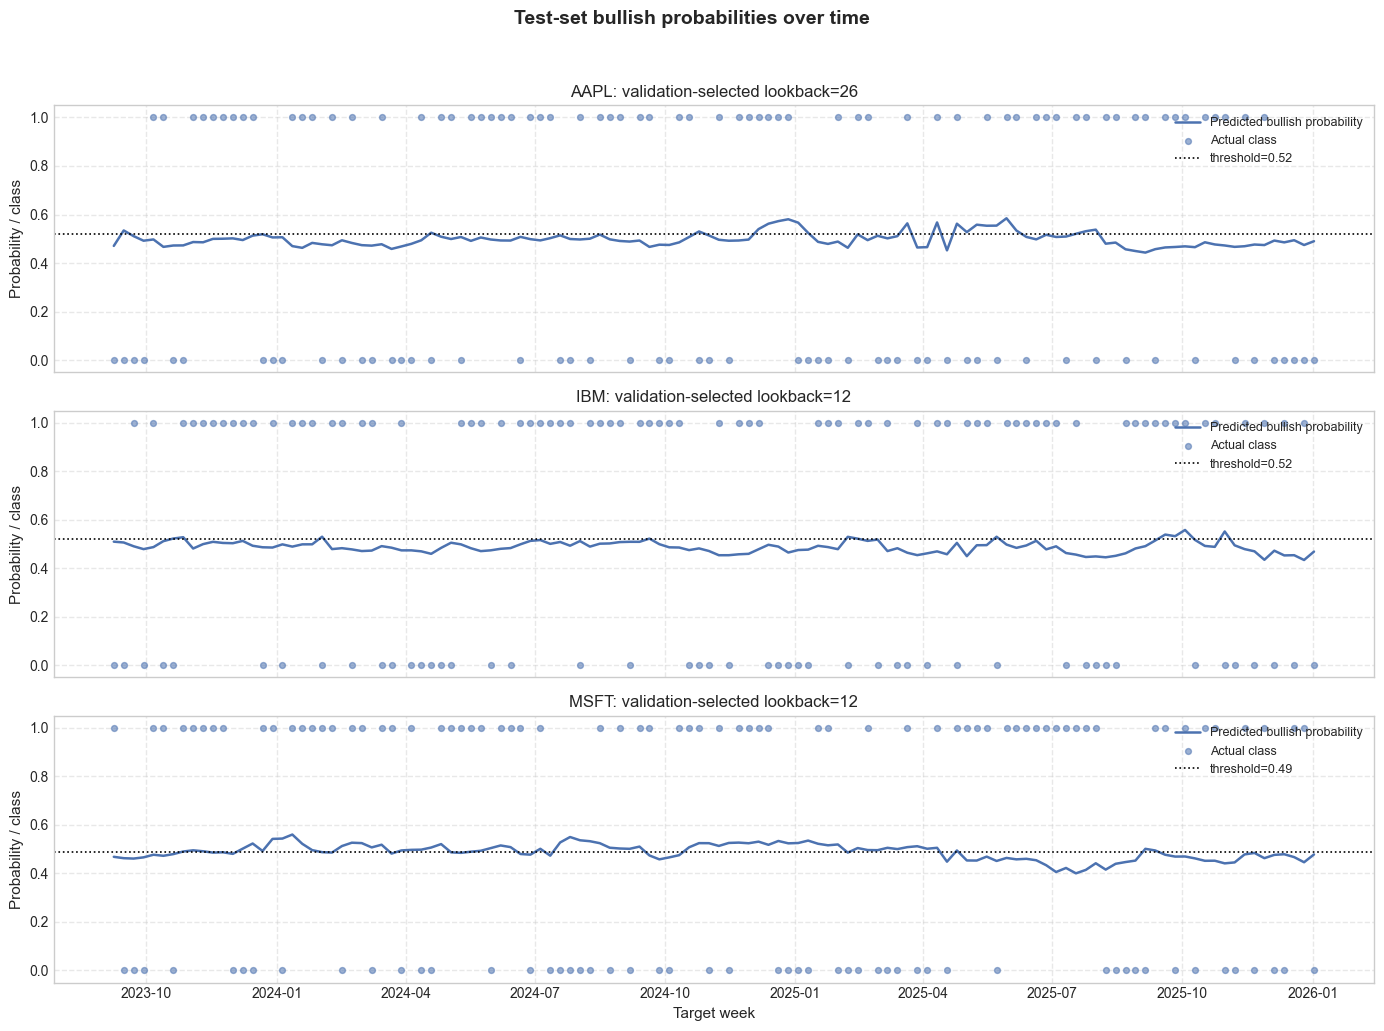

In [47]:
selected_test_df["Actual_State"] = np.where(selected_test_df["y_true"] == 1, "Bullish", "Bearish")

fig, axes = plt.subplots(1, len(tickers), figsize=(5.4 * len(tickers), 4.1), sharey=True)
if len(tickers) == 1:
    axes = [axes]

bins = np.linspace(0, 1, 21)
for ax, ticker in zip(axes, tickers):
    df_t = selected_test_df.loc[selected_test_df["Ticker"] == ticker]
    decision_threshold = threshold_for_selected_ticker(ticker)
    for state in ["Bearish", "Bullish"]:
        values = df_t.loc[df_t["Actual_State"] == state, "y_prob"]
        ax.hist(
            values,
            bins=bins,
            density=True,
            alpha=0.45,
            label=state,
            color=STATE_COLORS[state],
            edgecolor="white",
        )
    ax.axvline(decision_threshold, color="black", linestyle=":", linewidth=1.5, label=f"threshold={decision_threshold:.2f}")
    ax.set_xlim(0, 1)
    ax.set_title(ticker)
    ax.set_xlabel("Predicted bullish probability")
    ax.grid(True, linestyle="--", alpha=0.45)

axes[0].set_ylabel("Density")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
fig.suptitle("Predicted probability distributions by true test class", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 0.88, 0.94])
save_plot("weekly_lstm_selected_probability_distributions.png")
plt.show()

if {"Target_Date"}.issubset(selected_test_df.columns):
    selected_test_df["Target_Date"] = pd.to_datetime(selected_test_df["Target_Date"])
    fig, axes = plt.subplots(len(best_by_ticker_df), 1, figsize=(14, 3.5 * len(best_by_ticker_df)), sharex=True, sharey=True)
    if len(best_by_ticker_df) == 1:
        axes = [axes]

    for ax, row in zip(axes, best_by_ticker_df.itertuples(index=False)):
        df_t = selected_test_df.loc[selected_test_df["Ticker"] == row.ticker].sort_values("Target_Date")
        decision_threshold = float(row.decision_threshold)
        ax.plot(df_t["Target_Date"], df_t["y_prob"], linewidth=1.8, label="Predicted bullish probability")
        ax.scatter(
            df_t["Target_Date"],
            df_t["y_true"],
            s=18,
            alpha=0.55,
            label="Actual class",
        )
        ax.axhline(decision_threshold, color="black", linestyle=":", linewidth=1.2, label=f"threshold={decision_threshold:.2f}")
        ax.set_title(f"{row.ticker}: validation-selected lookback={row.lookback}")
        ax.set_ylabel("Probability / class")
        ax.legend(loc="upper right")
        ax.grid(True, linestyle="--", alpha=0.45)

    axes[-1].set_xlabel("Target week")
    fig.suptitle("Test-set bullish probabilities over time", fontsize=14, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    save_plot("weekly_lstm_selected_probabilities_over_time.png")
    plt.show()


### Training curves

Training curves help diagnose overfitting and unstable learning. The selected settings below are the same validation-selected lookbacks used in the test diagnostics.

Saved plot: outputs\weekly_lstm\plots\weekly_lstm_selected_training_loss.png


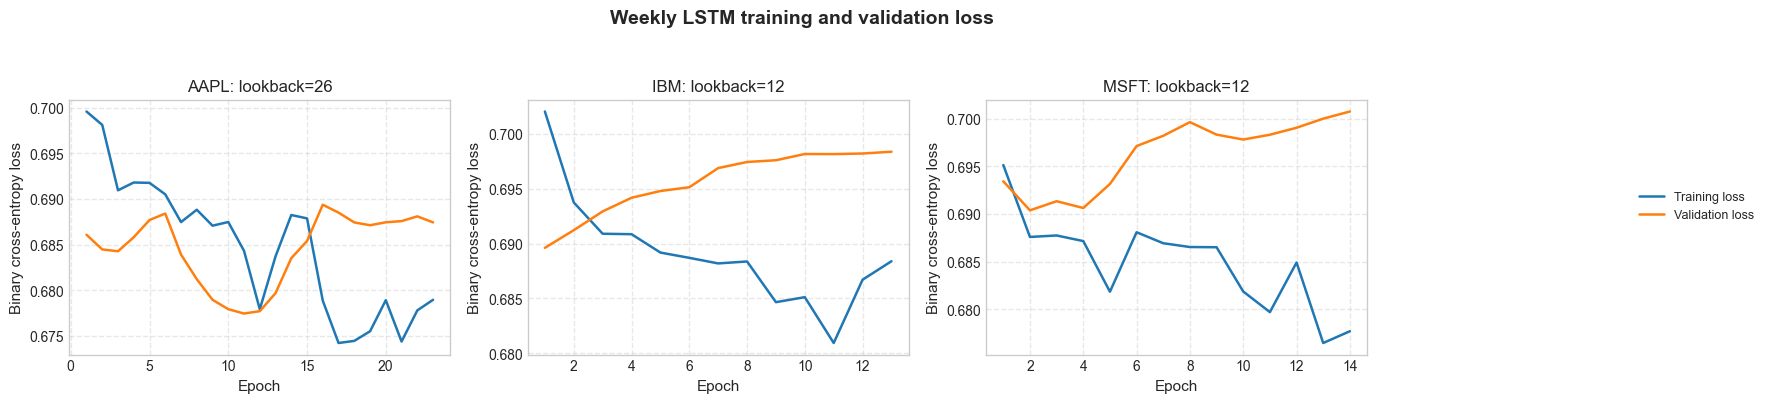

Saved plot: outputs\weekly_lstm\plots\weekly_lstm_selected_training_auc.png


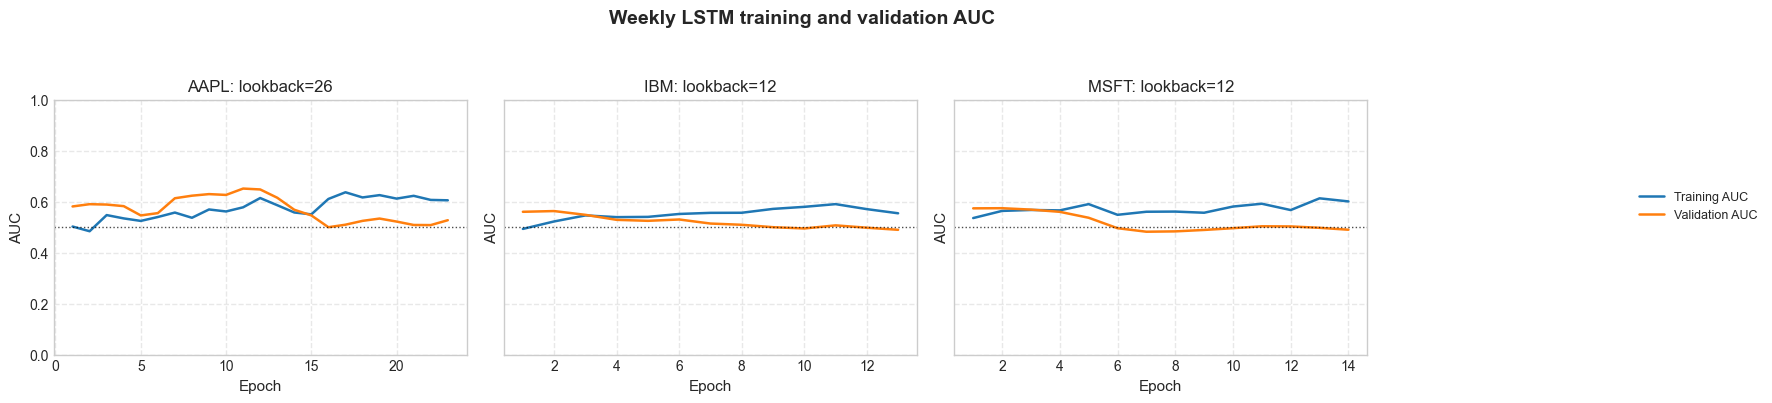

Saved plot files:
outputs\weekly_lstm\plots\weekly_lstm_metrics_by_lookback.png
outputs\weekly_lstm\plots\weekly_lstm_vs_naive_benchmarks.png
outputs\weekly_lstm\plots\weekly_lstm_selected_confusion_matrices.png
outputs\weekly_lstm\plots\weekly_lstm_selected_roc_curves.png
outputs\weekly_lstm\plots\weekly_lstm_selected_probability_distributions.png
outputs\weekly_lstm\plots\weekly_lstm_selected_probabilities_over_time.png
outputs\weekly_lstm\plots\weekly_lstm_selected_training_loss.png
outputs\weekly_lstm\plots\weekly_lstm_selected_training_auc.png


In [48]:
selected_keys_df = best_by_ticker_df[["ticker", "lookback"]].copy()
selected_history_df = weekly_lstm_history_df.merge(selected_keys_df, on=["ticker", "lookback"], how="inner")

fig, axes = plt.subplots(1, len(tickers), figsize=(5.4 * len(tickers), 4.1), sharey=False)
if len(tickers) == 1:
    axes = [axes]

for ax, ticker in zip(axes, tickers):
    df_t = selected_history_df.loc[selected_history_df["ticker"] == ticker].sort_values("epoch")
    if df_t.empty:
        ax.set_visible(False)
        continue
    lookback = int(df_t["lookback"].iloc[0])
    ax.plot(df_t["epoch"], df_t["loss"], linewidth=1.8, label="Training loss", color="tab:blue")
    ax.plot(df_t["epoch"], df_t["val_loss"], linewidth=1.8, label="Validation loss", color="tab:orange")
    ax.set_title(f"{ticker}: lookback={lookback}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Binary cross-entropy loss")
    ax.grid(True, linestyle="--", alpha=0.45)

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
fig.suptitle("Weekly LSTM training and validation loss", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 0.86, 0.94])
save_plot("weekly_lstm_selected_training_loss.png")
plt.show()

if {"auc", "val_auc"}.issubset(selected_history_df.columns):
    fig, axes = plt.subplots(1, len(tickers), figsize=(5.4 * len(tickers), 4.1), sharey=True)
    if len(tickers) == 1:
        axes = [axes]

    for ax, ticker in zip(axes, tickers):
        df_t = selected_history_df.loc[selected_history_df["ticker"] == ticker].sort_values("epoch")
        if df_t.empty:
            ax.set_visible(False)
            continue
        lookback = int(df_t["lookback"].iloc[0])
        ax.plot(df_t["epoch"], df_t["auc"], linewidth=1.8, label="Training AUC", color="tab:blue")
        ax.plot(df_t["epoch"], df_t["val_auc"], linewidth=1.8, label="Validation AUC", color="tab:orange")
        ax.axhline(0.5, color="black", linestyle=":", linewidth=1, alpha=0.7)
        ax.set_ylim(0, 1)
        ax.set_title(f"{ticker}: lookback={lookback}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("AUC")
        ax.grid(True, linestyle="--", alpha=0.45)

    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
    fig.suptitle("Weekly LSTM training and validation AUC", fontsize=14, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 0.86, 0.94])
    save_plot("weekly_lstm_selected_training_auc.png")
    plt.show()

print("Saved plot files:")
for path in saved_plot_paths:
    print(path)


## 8. Final sanity checks

In [49]:
expected_runs = len(tickers) * len(lookbacks)
if len(weekly_lstm_results_df) != expected_runs:
    raise ValueError(f"Expected {expected_runs} LSTM result rows, got {len(weekly_lstm_results_df)}.")

required_metric_cols = [
    "decision_threshold",
    "best_val_threshold_balanced_accuracy",
    "val_accuracy",
    "val_balanced_accuracy",
    "val_f1",
    "val_roc_auc",
    "val_cohen_kappa",
    "val_share_predicted_bullish",
    "test_accuracy",
    "test_balanced_accuracy",
    "test_f1",
    "test_roc_auc",
    "test_cohen_kappa",
    "test_share_predicted_bullish",
    "degenerate_prediction_warning",
]
for col in required_metric_cols:
    if col not in weekly_lstm_results_df.columns:
        raise ValueError(f"Missing metric column: {col}")

if not weekly_lstm_results_df["decision_threshold"].between(0.05, 0.95).all():
    raise ValueError("Decision thresholds must be selected from the 0.05 to 0.95 validation grid.")

silent_degenerate = weekly_lstm_results_df.loc[
    (
        (weekly_lstm_results_df["test_share_predicted_bullish"] <= DEGENERATE_SHARE_CUTOFF)
        | (weekly_lstm_results_df["test_share_predicted_bullish"] >= 1 - DEGENERATE_SHARE_CUTOFF)
    )
    & (~weekly_lstm_results_df["degenerate_prediction_warning"].astype(bool))
]
if not silent_degenerate.empty:
    raise ValueError("A degenerate prediction pattern was not flagged with a warning.")

required_output_files = [
    OUTPUT_DIR / "weekly_lstm_results.csv",
    OUTPUT_DIR / "weekly_lstm_predictions.csv",
    OUTPUT_DIR / "weekly_lstm_training_history.csv",
    OUTPUT_DIR / "weekly_lstm_threshold_search.csv",
    OUTPUT_DIR / "weekly_lstm_benchmark_results.csv",
    OUTPUT_DIR / "weekly_lstm_all_results.csv",
    OUTPUT_DIR / "weekly_lstm_best_by_ticker.csv",
    OUTPUT_DIR / "weekly_lstm_ranked_results.csv",
]

missing_output_files = [path for path in required_output_files if not path.exists()]
if missing_output_files:
    raise FileNotFoundError(f"Missing saved output files: {missing_output_files}")

missing_plot_files = [path for path in EXPECTED_PLOT_FILES if not path.exists()]
if missing_plot_files:
    raise FileNotFoundError(f"Missing saved plot files: {missing_plot_files}")

for ticker in tickers:
    for lookback in lookbacks:
        model_path = MODEL_DIR / f"weekly_lstm_{ticker}_lookback_{lookback}.keras"
        if not model_path.exists():
            raise FileNotFoundError(f"Missing saved model: {model_path}")

print("Training runs completed:", len(weekly_lstm_results_df))
print("Prediction rows:", len(weekly_lstm_predictions_df))
print("Threshold-search rows:", len(weekly_lstm_threshold_search_df))
print("Degenerate warnings:", int(weekly_lstm_results_df["degenerate_prediction_warning"].sum()))
print("Expected plot files:", len(EXPECTED_PLOT_FILES))
print("All required weekly LSTM model, output, and plot files exist.")
print("No HMM features were used in this baseline weekly LSTM notebook.")


Training runs completed: 12
Prediction rows: 2916
Threshold-search rows: 1092
Degenerate warnings: 2
Expected plot files: 8
All required weekly LSTM model, output, and plot files exist.
No HMM features were used in this baseline weekly LSTM notebook.


## Summary

This notebook trains a baseline weekly LSTM classifier for each ticker and each weekly lookback window: 4, 8, 12, and 26 weeks. The model uses a compact weekly architecture with one 16-unit LSTM layer, one 8-unit dense layer, dropout, class-balanced training weights, and a sigmoid output for next-week bullish probability.

The notebook compares the LSTM against naive benchmarks, saves metrics and predictions, selects a decision threshold using validation balanced accuracy only, creates research plots for model comparison and diagnostics, and selects the best lookback using validation ROC-AUC first and validation balanced accuracy second. Test results should be interpreted only after the validation-based selection step.

The notebook explicitly flags degenerate classifiers that predict almost all Bullish or almost all Bearish on the test set. The next modelling step is to create `hmm_regime_weekly.ipynb`, fit the weekly return-only HMM using `Weekly_Log_Return`, and then build `weekly_hmm_informed_lstm.ipynb`.